Saving 1331921.jpeg to 1331921 (1).jpeg


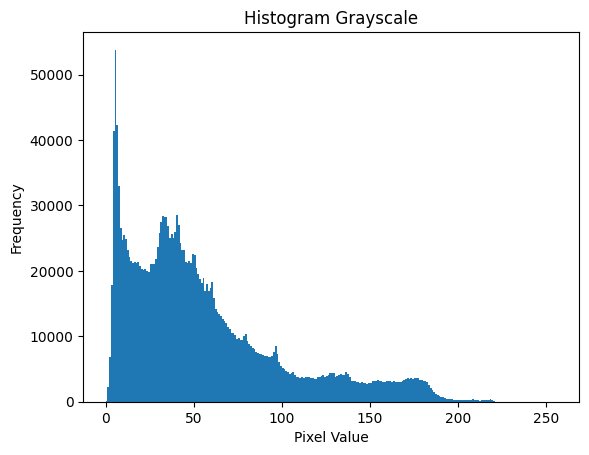

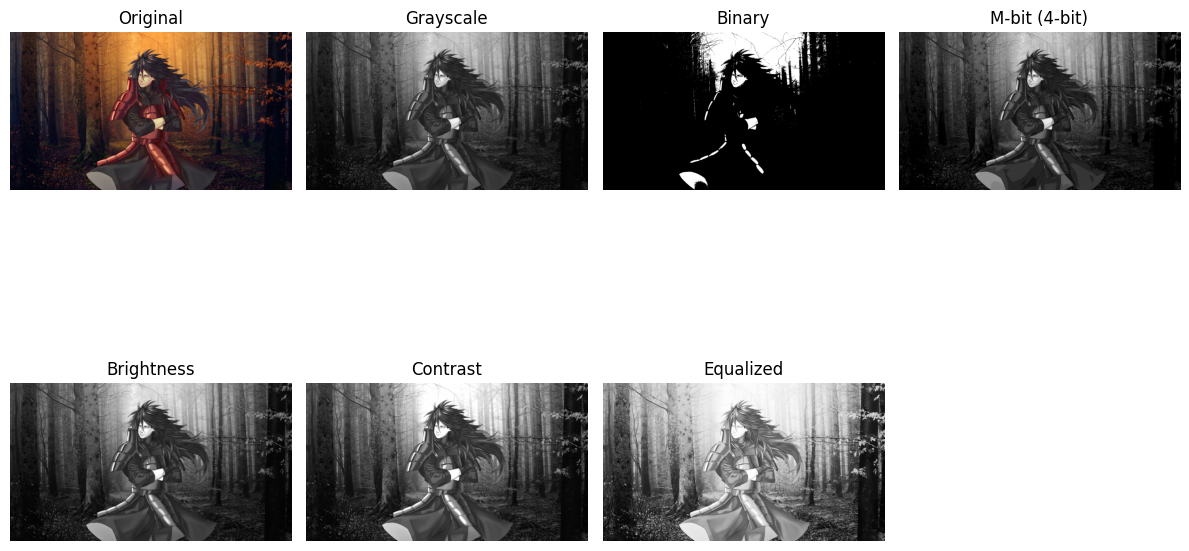

In [5]:
# ================================
# PROGRAM PENGOLAHAN CITRA DIGITAL
# ================================

# 1. Upload gambar
from google.colab import files
uploaded = files.upload()

# 2. Import library
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 3. Baca gambar
img = cv2.imread('1331921.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ================================
# 1. RGB ke Grayscale
# ================================
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# ================================
# 2. Grayscale ke Biner
# ================================
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# ================================
# 3. Grayscale ke M-bit (4-bit)
# ================================
bit = 4
levels = 2**bit
mbit = np.floor(gray / (256/levels)) * (256/levels)
mbit = mbit.astype(np.uint8)

# ================================
# 4. Brightness
# ================================
brightness = 50
bright_img = cv2.add(gray, brightness)

# ================================
# 5. Contrast
# ================================
alpha = 1.5
contrast_img = cv2.convertScaleAbs(gray, alpha=alpha, beta=0)

# ================================
# 6. Histogram
# ================================
plt.figure()
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.title("Histogram Grayscale")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# ================================
# 7. Histogram Equalization
# ================================
equalized = cv2.equalizeHist(gray)

# ================================
# Tampilkan semua hasil
# ================================
titles = [
    'Original',
    'Grayscale',
    'Binary',
    'M-bit (4-bit)',
    'Brightness',
    'Contrast',
    'Equalized'
]

images = [
    img_rgb,
    gray,
    binary,
    mbit,
    bright_img,
    contrast_img,
    equalized
]

plt.figure(figsize=(12,8))

for i in range(len(images)):
    plt.subplot(2,4,i+1)

    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()